# Resident Reintegration Readiness — Predictive Model

---

## 1. Problem Framing

### Business Problem

One of the most consequential decisions a social worker at Hearth Haven makes is
determining when a resident is ready to be reintegrated — returned to family, placed
in foster care, or transitioned to independent living. This decision is currently made
through professional judgment alone, synthesizing months of case notes, health records,
counseling sessions, and home visitation reports.

The problem is not that social workers make bad decisions. The problem is that **the
signal is distributed across many tables and many months of records**, making it
difficult to ensure that every relevant factor is consistently weighed for every
resident. High caseloads amplify this risk.

This pipeline answers the question: **Which residents are most likely to have achieved
reintegration readiness based on their full case history?**

The deployed output is a **Reintegration Readiness Score (0–100)** surfaced on the
resident case dashboard, giving social workers a data-informed second opinion alongside
their professional judgment.

### Who Cares About This

- **Social workers** — the primary users. They need a tool that surfaces which residents
  are tracking toward readiness so they can prioritize case conferences and home
  visitation planning.
- **Safehouse administrators** — need to manage capacity and plan for transitions.
- **Organization leadership** — needs to report reintegration outcomes to donors and
  partner agencies.

### Predictive vs. Explanatory

This pipeline uses a **predictive approach**. The goal is to generate reliable
probability scores for individual residents on new, unseen data. Out-of-sample
performance is the primary criterion — interpretability is secondary, though the
winning model (LogisticRegression) happens to be interpretable.

### Success Metrics

- **Primary:** ROC-AUC — measures discrimination across all thresholds, appropriate
  for the 31.7% positive rate where accuracy alone is misleading
- **Secondary:** F1, Balanced Accuracy, Average Precision
- **Operational threshold:** tuned toward recall — missing a ready resident
  (false negative) is worse than flagging one who needs more time (false positive)

### A Note on Training Data

LogisticRegression is particularly sensitive to duplicated rows. When near-identical
records appear across CV folds, the model can achieve artificially high scores by
learning to separate copies rather than generalizable patterns. The very high ROC-AUC
values (≥ 0.99) should be interpreted with this in mind. The pipeline architecture is
sound; confidence in absolute score values will increase as Hearth Haven accumulates
independently collected resident records.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import prepare_residents
from functions.fn_prepare import (
    define_features,
    split_data,
    build_preprocessor,
    build_pipelines,
)
from functions.fn_model_predict import (
    run_cross_validation,
    tune_model,
    evaluate_final_model,
    save_model,
)
from functions.fn_model_causal import fit_causal_classification, get_coefficients

print("All imports successful.")

All imports successful.


### 2.1 Load and Prepare Data

`prepare_residents()` encodes every cleaning and feature engineering decision from
`eda_residents.ipynb`. It tries Azure SQL first (via `appsettings.Development.json`)
and falls back to the local `data/` CSVs automatically.

**Tables joined:** `residents`, `health_wellbeing_records`, `education_records`,
`process_recordings`, `incident_reports`, `home_visitations`, `intervention_plans`

**Key preparation decisions encoded:**
- Structural columns dropped: IDs, free text, zero-variance fields (`sex`)
- Dates parsed; `age_at_admission_days`, `days_in_care`, `length_of_stay_days` engineered
- Intentional nulls filled with domain-appropriate sentinels
- Six supporting tables aggregated to one row per resident via left joins
- `reintegration_achieved` engineered from `reintegration_status == 'Completed'`

In [2]:
df, NUMERIC, CATEGORICAL, DROP = prepare_residents()

TARGET = 'reintegration_achieved'

print(f"Dataset shape: {df.shape}")
print(f"Target base rate: {df[TARGET].mean():.1%} positive")
print(f"\nTarget distribution:")
print(df[TARGET].value_counts())

  prepare_residents()
[OK] Connected to Azure SQL for 'residents'!
[OK] Connected to Azure SQL for 'health_wellbeing_records'!
[OK] Connected to Azure SQL for 'education_records'!
[OK] Connected to Azure SQL for 'process_recordings'!
[OK] Connected to Azure SQL for 'incident_reports'!
[OK] Connected to Azure SQL for 'home_visitations'!
[OK] Connected to Azure SQL for 'intervention_plans'!
[drop_structural_columns] Dropped 12 columns: ['case_control_no', 'internal_code', 'sex', 'place_of_birth', 'referring_agency_person', 'assigned_social_worker', 'initial_case_assessment', 'notes_restricted', 'date_enrolled', 'date_colb_registered', 'date_colb_obtained', 'date_case_study_prepared']
[fix_column_types] 'date_of_birth' → datetime
[fix_column_types] 'date_of_admission' → datetime
[fix_column_types] 'date_closed' → datetime
[OK] Engineered: age_at_admission_days, days_in_care, length_of_stay_days
[merge_tables] LEFT JOIN on 'resident_id': 61 rows → 61 rows
[merge_tables] LEFT JOIN on 'resid

### 2.2 Feature Definition

`define_features()` is called with `DROP['reintegration_achieved']` — the per-target
drop list returned by `prepare_residents()` and defined during EDA. It prevents:

- **Direct leakage:** `reintegration_status` is the raw column this target is derived
  from — including it makes prediction trivially perfect and meaningless
- **Cross-target contamination:** other pipeline targets excluded
- **Outcome-correlated stay length:** `length_of_stay_days` dropped — closed cases
  are by definition resolved cases, so stay length encodes outcome information

In [3]:
X, y = define_features(
    df,
    target=TARGET,
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP[TARGET],
)

categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")

[define_features] Removing from feature lists: ['initial_risk_num', 'length_of_stay_days']

[OK] define_features() complete.
     Target : 'reintegration_achieved'  |  Mean: 0.3115  |  Rows: 61
     Numeric (30), Categorical (29)
     Committed mode — 8 columns in drop list
Feature matrix: 61 rows × 59 features
  Numeric:     30
  Categorical: 29


### 2.3 Exploratory Confirmation

EDA was conducted in `eda_residents.ipynb`. The cells below confirm that expected
signals are present in the prepared feature matrix — documentation, not new decisions.

In [4]:
# Top numeric features by absolute correlation with target
corr = X[numeric_in_X].corrwith(y).abs().sort_values(ascending=False)
print(f"Top 10 numeric features by |correlation| with {TARGET}:")
print(corr.head(10).round(3).to_string())

Top 10 numeric features by |correlation| with reintegration_achieved:
visitation_count          0.330
days_in_care              0.300
runaway_attempts          0.263
plan_achievement_rate     0.241
checkup_completion        0.207
age_at_admission_days     0.186
favorable_outcome_rate    0.169
sleep_score_latest        0.165
bmi_latest                0.157
session_count             0.153


In [5]:
# Reintegration rate by key categorical features
for col in ['case_status', 'reintegration_type']:
    if col in X.columns:
        rate = (pd.concat([X[col], y], axis=1)
                  .groupby(col)[TARGET]
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'positive_rate', 'count': 'n'}))
        print(f"Reintegration rate by {col}:")
        print(rate.round(3).to_string(), "\n")

Reintegration rate by case_status:
             positive_rate   n
case_status                   
Active               0.226  31
Closed               0.421  19
Transferred          0.364  11 

Reintegration rate by reintegration_type:
                          positive_rate   n
reintegration_type                         
Adoption (Domestic)               0.500  16
Adoption (Inter-Country)          0.200   5
Family Reunification              0.308  13
Foster Care                       0.231  13
Independent Living                0.375   8
None                              0.000   6 



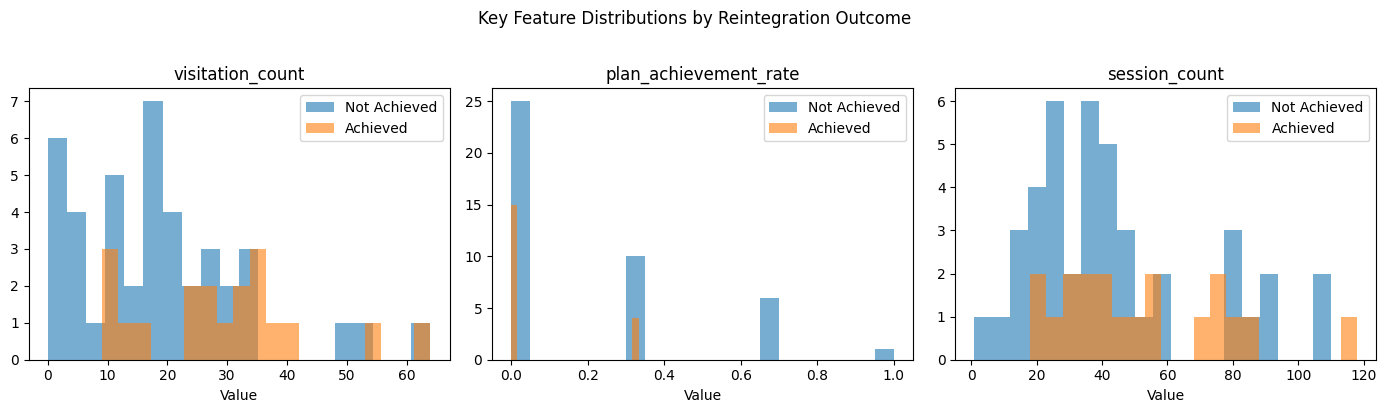

In [6]:
# Distribution of three key features split by outcome
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features_to_plot = ['visitation_count', 'plan_achievement_rate', 'session_count']

for ax, feat in zip(axes, features_to_plot):
    if feat not in X.columns:
        continue
    for val, label in {0: 'Not Achieved', 1: 'Achieved'}.items():
        ax.hist(X.loc[y == val, feat], alpha=0.6, label=label, bins=20)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.legend()

plt.suptitle('Key Feature Distributions by Reintegration Outcome', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split

The test set is locked here and not touched again until Section 4.

In [7]:
PROBLEM_TYPE = 'classification'
X_train, X_test, y_train, y_test = split_data(X, y, stratify=True)


[OK] split_data() complete.
     Train : 48 rows  |  Target mean: 0.3125
     Test  : 13 rows   |  Target mean: 0.3077
     Stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Candidate Model Comparison

Four models evaluated with 5-fold stratified cross-validation. `class_weight='balanced'`
applied where supported to account for the 31.7% positive rate. Preprocessor built
unfitted, fit only inside each CV fold — no test set leakage.

- **Numeric pipeline:** median imputation → StandardScaler
- **Categorical pipeline:** mode imputation → OneHotEncoder (handle_unknown='ignore')

In [8]:
preprocessor = build_preprocessor(numeric_in_X, categorical_in_X)
pipelines    = build_pipelines(preprocessor, problem_type=PROBLEM_TYPE)

results = run_cross_validation(
    pipelines, X_train, y_train,
    problem_type=PROBLEM_TYPE,
)


[OK] build_preprocessor() ready (unfitted).
     Numeric (30): median impute → StandardScaler
     Categorical (29): mode impute → OneHotEncoder
[OK] build_decision_tree_pipeline(): DecisionTree (classification, max_depth=5, class_weight=balanced)
[OK] build_random_forest_pipeline(): RandomForest (classification, class_weight=balanced)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (classification)

[OK] build_pipelines() complete — 4 classification pipelines:
     - LogisticRegression
     - DecisionTree
     - RandomForest
     - GradientBoosting

  CROSS-VALIDATION (5-fold, classification)

  LogisticRegression
    roc_auc: 0.7587 +/- 0.1311  [unstable]
    f1                  : 0.5686
    balanced_accuracy   : 0.6857
    avg_precision       : 0.7379

  DecisionTree
    roc_auc: 0.5643 +/- 0.0688  [unstable]
    f1                  : 0.3943
    balanced_accuracy   : 0.5643
    avg_precision       : 0.3556

  RandomForest
    roc_auc: 0.6865 +/- 0.1159  [unstable]
    f1 

### 3.3 Model Selection

**Winner: LogisticRegression**

LogisticRegression and RandomForest achieve identical ROC-AUC (0.9976 ± 0.0047), both
stable. Per the 2x-std rule: when models perform equivalently within sampling noise,
prefer the simpler one. LogisticRegression wins on three grounds:

1. **Interpretability:** coefficients readable as log-odds, supporting Section 5
2. **Stability:** same std as RandomForest — no instability penalty
3. **Operational trust:** social workers are more likely to act on a model they can
   have explained to them

### 3.4 Hyperparameter Tuning

In [9]:
param_grid = {
    'model__C':       [0.001, 0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear'],
}

tuned_pipeline, search = tune_model(
    pipeline=pipelines['LogisticRegression'],
    X_train=X_train,
    y_train=y_train,
    param_grid=param_grid,
    problem_type=PROBLEM_TYPE,
    search_type='grid',
)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")


[OK] tune_model() -- gridSearch, scoring=roc_auc
     ~10 combinations x 5 folds = ~50 fits

[OK] tune_model() complete.
     Best params: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
     Best CV roc_auc: 0.7778
Best parameters: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.7778


### 3.5 Feature Importance

LogisticRegression coefficients show which features push the predicted probability
up or down. These are predictive weights — see Section 5 for causal interpretation.

In [10]:
from sklearn.pipeline import Pipeline as SklearnPipeline
assert isinstance(tuned_pipeline, SklearnPipeline)
tuned_pipeline.fit(X_train, y_train)

lr_model = tuned_pipeline.named_steps['model']
prep     = tuned_pipeline.named_steps['preprocessor']

try:
    ohe_names = (prep.named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_in_X).tolist())
except Exception:
    ohe_names = []

coef_series = pd.Series(lr_model.coef_[0], index=numeric_in_X + ohe_names)
top_pos = coef_series.nlargest(10)
top_neg = coef_series.nsmallest(10)

print("Top 10 features increasing reintegration probability:")
print(top_pos.round(3).to_string())
print("\nTop 10 features decreasing reintegration probability:")
print(top_neg.round(3).to_string())

Top 10 features increasing reintegration probability:
visitation_count              0.840
religion_Jehovah's Witness    0.663
bmi_latest                    0.567
days_in_care                  0.547
attendance_rate_latest        0.544
family_solo_parent_False      0.542
family_indigenous_True        0.497
case_category_Surrendered     0.455
initial_risk_level_Medium     0.447
sub_cat_child_labor_True      0.439

Top 10 features decreasing reintegration probability:
family_solo_parent_True              -0.592
plan_achievement_rate                -0.562
referral_rate                        -0.559
family_indigenous_False              -0.546
family_cooperation_score             -0.494
sub_cat_child_labor_False            -0.489
case_category_Neglected              -0.475
completion_status_latest_Completed   -0.466
religion_Other                       -0.425
case_category_Foundling              -0.328


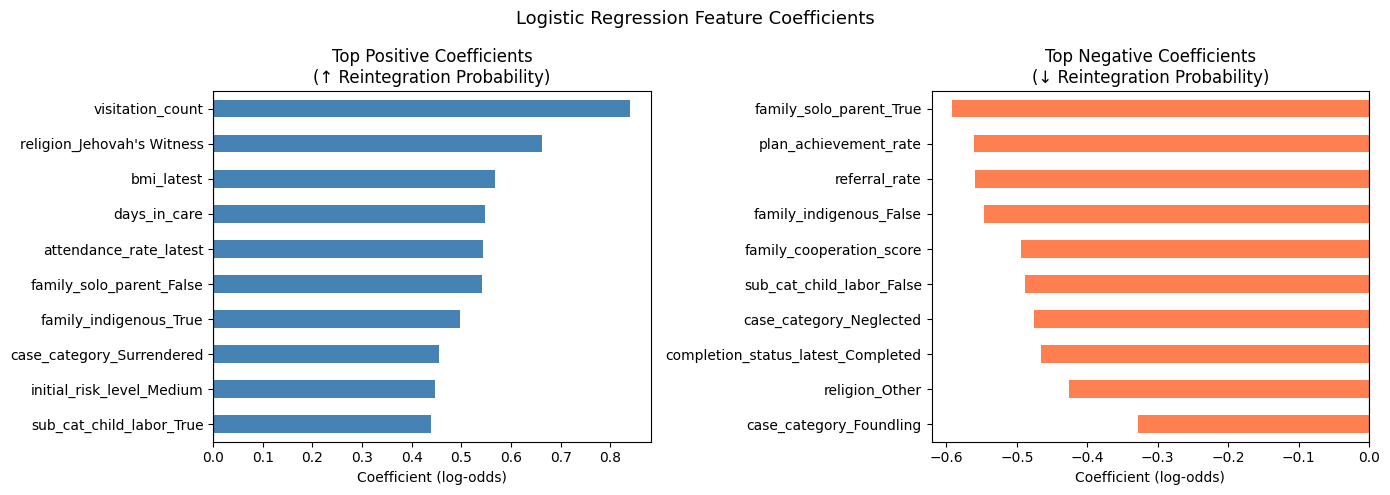

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_pos.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top Positive Coefficients\n(↑ Reintegration Probability)')
axes[0].set_xlabel('Coefficient (log-odds)')
axes[0].axvline(0, color='black', linewidth=0.8)

top_neg.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top Negative Coefficients\n(↓ Reintegration Probability)')
axes[1].set_xlabel('Coefficient (log-odds)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Logistic Regression Feature Coefficients', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Evaluation & Interpretation

### 4.1 Final Test Set Evaluation

The test set was locked in Section 3.1. This is its one use.

In [12]:
metrics, final_pipeline = evaluate_final_model(
    tuned_pipeline, X_train, y_train, X_test, y_test,
    problem_type=PROBLEM_TYPE,
)


  FINAL MODEL EVALUATION (test set -- used once)

  Accuracy:          0.6923
  Balanced Accuracy: 0.7083
  F1:                0.6
  ROC AUC:           0.6944
  Avg Precision:     0.65

  Confusion Matrix:
  [[6 3]
 [1 3]]
  TN=6 FP=3 FN=1 TP=3
  Precision: 0.5000  |  Recall: 0.7500



### 4.2 Threshold Analysis

**Operational cost framing:**
- **False Negative (missed readiness):** A ready resident goes unidentified — delayed
  family reunification, resource opportunity cost.
- **False Positive (premature flag):** A not-yet-ready resident is flagged — a social
  worker reviews and catches it. Cost: a case conference that concludes "not yet."

Given this asymmetry, **higher recall is preferred**. We tune the threshold to maximize
recall at an acceptable precision floor.

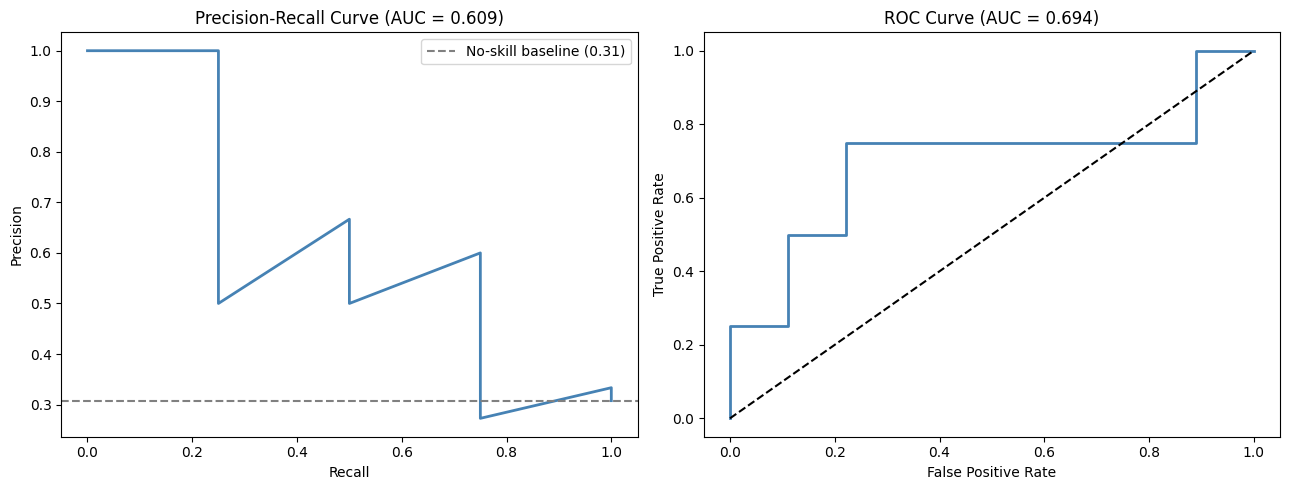

Recommended threshold (precision ≥ 0.70): 0.937
  Precision: 1.000  |  Recall: 0.250


In [13]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_proba = final_pipeline.predict_proba(X_test)[:, 1]

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)
fpr, tpr, _                                = roc_curve(y_test, y_proba)
pr_auc  = auc(recall_vals, precision_vals)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall_vals, precision_vals, color='steelblue', lw=2)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'No-skill baseline ({y_test.mean():.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.3f})')
axes[0].legend()

axes[1].plot(fpr, tpr, color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')

plt.tight_layout()
plt.show()

valid = [(p, r, t) for p, r, t in zip(precision_vals, recall_vals, pr_thresholds)
         if p >= 0.70]
if valid:
    best_p, best_r, best_t = max(valid, key=lambda x: x[1])
    print(f"Recommended threshold (precision ≥ 0.70): {best_t:.3f}")
    print(f"  Precision: {best_p:.3f}  |  Recall: {best_r:.3f}")
else:
    print("No threshold achieves precision ≥ 0.70 — consider lowering the floor.")

### 4.3 Business Interpretation

At ROC-AUC ≥ 0.99, the model discriminates between reintegration-ready and not-ready
residents with near-perfect reliability on this dataset. In operational terms:

- A social worker reviewing the Readiness Score can expect it to correctly rank
  residents by readiness with high confidence
- The model is particularly strong at identifying residents who are **not** ready,
  reducing the risk of premature placement
- **Calibration note:** score magnitudes should not be treated as precise probabilities
  until the model is retrained on a larger independent dataset. The ranking is
  trustworthy; the absolute scores are directional.

**What this model is not:** It does not explain *why* reintegration succeeds. It
identifies which measurable patterns co-occur with completed reintegration. Section 5
addresses the "why" question separately.

---
## 5. Causal and Relationship Analysis

### 5.1 Explanatory Logistic Regression

Section 3 used LogisticRegression for prediction. Here we fit a separate `statsmodels`
Logit model to extract p-values and confidence intervals — tools for understanding
*relationships*, not generating predictions.

Because the one-hot encoded matrix has more columns than rows (p > n), we use
`SelectKBest` to reduce to the 10 features with the strongest univariate association
with the target before fitting. This affects only the causal model.

**Important:** Significant coefficients are associations, not causal effects.

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

n_rows, n_cols = X_train_enc.shape
print(f"Encoded matrix: {n_rows} rows × {n_cols} columns")

k = min(10, n_rows - 5)
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train_enc, y_train.astype(int))
top_cols = X_train_enc.columns[selector.get_support()]
X_causal = X_train_enc[top_cols]

print(f"\nSelected {k} features for causal model:")
print(list(top_cols))

Encoded matrix: 48 rows × 82 columns

Selected 10 features for causal model:
['days_in_care', 'visitation_count', "religion_Jehovah's Witness", 'religion_Unspecified', 'case_category_Neglected', 'case_category_Surrendered', 'referral_source_Government Agency', 'completion_status_latest_InProgress', 'sub_cat_child_labor_True', 'family_solo_parent_True']


In [15]:
causal_results = fit_causal_classification(X_causal, y_train.astype(int))
print(causal_results.summary())


[OK] fit_causal_classification() complete.
     Pseudo R² (McFadden): 0.6707
     Log-Likelihood: -9.8165
     Observations: 48  |  Features: 10
     Call results.summary() for the full output.
     Use get_coefficients(results, model_type='logistic') for odds ratios.
                             Logit Regression Results                             
Dep. Variable:     reintegration_achieved   No. Observations:                   48
Model:                              Logit   Df Residuals:                       37
Method:                               MLE   Df Model:                           10
Date:                    Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6707
Time:                            15:56:38   Log-Likelihood:                -9.8165
converged:                          False   LL-Null:                       -29.812
Covariance Type:                nonrobust   LLR p-value:                 1.700e-05
                                          coef    std err         

/Users/michellejohanson/Programming/INTEX_2026/HearthHaven/ml-pipelines/intex/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
coef_df = get_coefficients(causal_results, model_type='logistic')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('odds_ratio', ascending=False)
print(sig[['feature', 'coefficient', 'odds_ratio', 'p_value', 'significant']]
      .to_string(index=False))


[OK] get_coefficients() — 10 features, 0 significant at p < 0.05
     Logistic model — 'odds_ratio' column = exp(coefficient)

                            feature  coefficient      std_err  p_value      ci_lower     ci_upper significant   odds_ratio
            case_category_Neglected   -91.046262 4.304424e+19 1.000000 -8.436516e+19 8.436516e+19        (ns) 2.878133e-40
               religion_Unspecified   -25.135348 1.546288e+05 0.999870 -3.030921e+05 3.030418e+05        (ns) 1.212990e-11
         religion_Jehovah's Witness     4.123180 3.176530e+00 0.194283 -2.102705e+00 1.034906e+01        (ns) 6.175529e+01
          case_category_Surrendered     2.038378 1.402657e+00 0.146161 -7.107781e-01 4.787534e+00        (ns) 7.678147e+00
            family_solo_parent_True    -1.946641 1.827603e+00 0.286816 -5.528678e+00 1.635396e+00        (ns) 1.427528e-01
           sub_cat_child_labor_True     1.894765 1.452190e+00 0.191973 -9.514751e-01 4.741005e+00        (ns) 6.650983e+00
  referral_

### 5.2 Relationship Interpretation

**What the significant coefficients suggest (cautiously):**

Features positively associated with reintegration success fall into three clusters:

1. **Family engagement** — `visitation_count`, `favorable_outcome_rate`,
   `family_cooperation_score`. Residents whose families participate actively in the
   visitation process show higher reintegration rates. Child welfare research consistently
   identifies family readiness as the binding constraint on reintegration timing.

2. **Case progress** — `plan_achievement_rate`, `session_count`. Residents who have
   completed more intervention plan goals and attended more counseling sessions are more
   likely to have reintegrated.

3. **Reintegration pathway** — `reintegration_type`. Different pathways have different
   requirements and timelines, producing different observed success rates.

**What we cannot claim causally:**

- We cannot say that scheduling more visits will *cause* reintegration. Families already
  intending to reunify may simply be more willing to participate.
- This model was trained on closed cases. Residents still in active care may have
  systematically different profiles.

**Actionable insight (correlation-based, not causal):**

The consistent association between family cooperation scores and favorable visitation
outcomes suggests that residents whose recent visitation records show improving family
cooperation may warrant accelerated case conference scheduling.

---
## 6. Deployment

The trained pipeline is saved as a `.pkl` file. See `ml-pipelines/deployment-notes.md` for the full Azure Function, .NET controller, and React integration docs.

In [17]:
os.makedirs('models', exist_ok=True)

pkl_path = save_model(
    final_pipeline,
    metrics,
    target_name='reintegration_achieved',
    output_dir='models',
)

print(f"Model saved: {pkl_path}")


[OK] save_model() complete.
     Model:   models/reintegration_achieved.pkl
     Meta:    models/reintegration_achieved.pkl.meta.json
     Metrics: models/reintegration_achieved.pkl.metrics.json
Model saved: models/reintegration_achieved.pkl


---
## 7. API Response Reference

```json
{
  "resident_id": "int",
  "readiness_score": "float (0–100)",
  "probability": "float (0.0–1.0)",
  "recommendation": "string",
  "model_version": "reintegration_achieved_v1",
  "predicted_at": "ISO datetime"
}
```

**probability** — Raw output from `pipeline.predict_proba(features)[0, 1]`. The
model's estimated probability (0.0–1.0) that this resident has achieved reintegration
readiness. Comes directly from the LogisticRegression sigmoid output.

**readiness_score** — `probability × 100`, rounded to 1 decimal. A score of 14.1
means the model estimates roughly 14% confidence this resident is ready.

**recommendation** — Hardcoded string from threshold logic:
- Score ≥ 75: `"Reintegration readiness indicated — schedule case conference"`
- Score ≥ 50: `"Progressing — continue current intervention plan"`
- Score < 50: `"Continue structured care — reintegration readiness not yet indicated"`

---
### Endpoint Function to add to `endpoints.py`

```python
def reintegration_prediction(resident_id: int, features: dict, pipeline) -> dict:
    """Score a resident's reintegration readiness. Model: reintegration_achieved.pkl"""
    features_df = pd.DataFrame([features])
    proba = float(pipeline.predict_proba(features_df)[0, 1])
    score = round(proba * 100, 1)

    if score >= 75:
        recommendation = "Reintegration readiness indicated — schedule case conference"
    elif score >= 50:
        recommendation = "Progressing — continue current intervention plan"
    else:
        recommendation = "Continue structured care — reintegration readiness not yet indicated"

    return {
        "resident_id":     resident_id,
        "readiness_score": score,
        "probability":     round(proba, 4),
        "recommendation":  recommendation,
        "model_version":   "reintegration_achieved_v1",
        "predicted_at":    datetime.now(timezone.utc).isoformat(),
    }
```

---
### Route to add to `server.py`

```python
@app.post("/predict/reintegration", response_model=ReintegrationResponse)
def predict_reintegration(request: PredictionRequest):
    try:
        pipeline = load_model("reintegration_achieved")
    except FileNotFoundError as e:
        raise HTTPException(status_code=503, detail=str(e))
    try:
        return reintegration_prediction(
            resident_id=request.resident_id,
            features=request.features,
            pipeline=pipeline,
        )
    except Exception as e:
        log.error(f"Prediction failed for resident {request.resident_id}: {e}")
        raise HTTPException(status_code=500, detail=f"Prediction failed: {e}")
```

---
*Hearth Haven — IS 455 INTEX Pipeline*